In [2]:
import math
import random
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn.linear_model

In [3]:
mango_data = pd.read_csv("../dx601-homework-06/mango-tiny.tsv", sep="\t")

In [4]:
mango_data

,green_rating,yellow_rating,softness,wrinkles,estimated_flavor,estimated_sweetness,rated_flavor
0,1,5,4,0,4,4,5
1,1,5,5,1,5,5,1
2,2,4,3,1,3,3,3
3,3,3,2,0,2,1,2
4,5,1,1,1,1,1,1
5,4,2,1,1,1,1,1
6,5,1,1,1,2,1,1
7,3,3,2,1,2,2,2


In [5]:
abalone = pd.read_csv("https://raw.githubusercontent.com/bu-cds-omds/dx601-examples/main/data/abalone.tsv", sep="\t")

In [6]:
abalone

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7
...,...,...,...,...,...,...,...,...,...
4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10


In [7]:
# Count Frequencies
freq = mango_data["green_rating"].value_counts()
freq

green_rating
1    2
3    2
5    2
2    1
4    1
Name: count, dtype: int64

In [8]:
join_prob = pd.crosstab(mango_data["yellow_rating"], mango_data["softness"], margins=False)

join_prob

softness,1,2,3,4,5
yellow_rating,,,,,
1,2,0,0,0,0
2,1,0,0,0,0
3,0,2,0,0,0
4,0,0,1,0,0
5,0,0,0,1,1


In [10]:
# Stack to convert to Series with tuple index, then dictionary
p2 = join_prob.stack().to_dict()
p2

{(1, 1): 2,
 (1, 2): 0,
 (1, 3): 0,
 (1, 4): 0,
 (1, 5): 0,
 (2, 1): 1,
 (2, 2): 0,
 (2, 3): 0,
 (2, 4): 0,
 (2, 5): 0,
 (3, 1): 0,
 (3, 2): 2,
 (3, 3): 0,
 (3, 4): 0,
 (3, 5): 0,
 (4, 1): 0,
 (4, 2): 0,
 (4, 3): 1,
 (4, 4): 0,
 (4, 5): 0,
 (5, 1): 0,
 (5, 2): 0,
 (5, 3): 0,
 (5, 4): 1,
 (5, 5): 1}

In [13]:
# Create cross-tabulation
joint_freq = pd.crosstab(mango_data['rated_flavor'], 
                          mango_data['yellow_rating'], 
                          margins=False)

# Extract only the column for yellow_rating=1
flavor_given_yellow1 = joint_freq[1]  # Column where yellow_rating=1

# Convert to probabilities (divide by sum of that column)
# Filter first, then convert
prob_dist = flavor_given_yellow1 / flavor_given_yellow1.sum()
p3 = prob_dist[prob_dist > 0].to_dict()
p3

{1: 1.0}

In [14]:
# This is simpler and gives you only the values that exist
yellow_1_data = mango_data[mango_data['yellow_rating'] == 1]
p3 = (yellow_1_data['rated_flavor'].value_counts() / len(yellow_1_data)).to_dict()

In [15]:
# Correlation between two columns
corr = mango_data['green_rating'].corr(mango_data['yellow_rating'])
print(f"Correlation: {corr}")

# Correlation matrix for all numeric columns
corr_matrix = mango_data.corr()
print(corr_matrix)

Correlation: -1.0
                     green_rating  yellow_rating  softness  wrinkles  \
green_rating             1.000000      -1.000000 -0.946514  0.384900   
yellow_rating           -1.000000       1.000000  0.946514 -0.384900   
softness                -0.946514       0.946514  1.000000 -0.256158   
wrinkles                 0.384900      -0.384900 -0.256158  1.000000   
estimated_flavor        -0.881917       0.881917  0.972629 -0.218218   
estimated_sweetness     -0.901498       0.901498  0.974939 -0.097590   
rated_flavor            -0.629941       0.629941  0.469545 -0.654654   

                     estimated_flavor  estimated_sweetness  rated_flavor  
green_rating                -0.881917            -0.901498     -0.629941  
yellow_rating                0.881917             0.901498      0.629941  
softness                     0.972629             0.974939      0.469545  
wrinkles                    -0.218218            -0.097590     -0.654654  
estimated_flavor             1

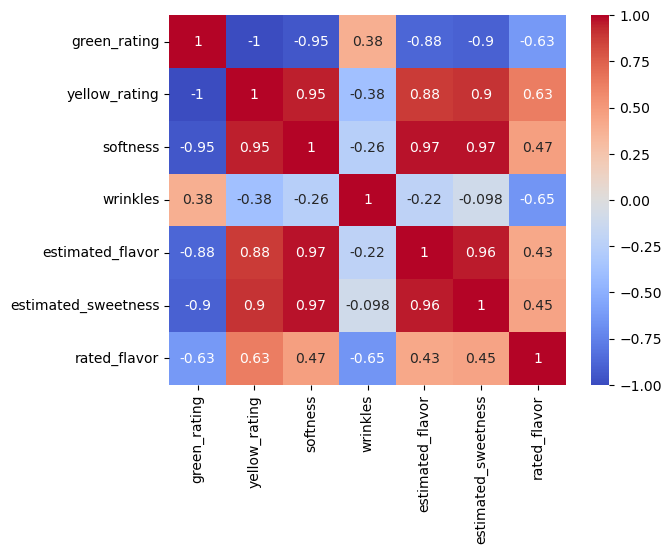

In [16]:
# Visualize with heatmap
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.show()

In [18]:
correlation = abalone['Whole_weight'].corr(abalone['Shucked_weight'])
# If correlation ≈ 0: likely independent
# If correlation far from 0: dependent
correlation


0.9694054567034335

In [ ]:
# L2 Loss = (predicted - actual)²
# Average L2 Loss = mean((predicted - actual)²)